# DiffQRCoder, latent (sandwich) version: SD 1.5 with the SD-VAE vs SD 1.5 with the SPNN codec

**Target:** an aesthetic QR code that scans to a Rick roll, `https://youtu.be/dQw4w9WgXcQ`.

[DiffQRCoder](DiffQRCoder-main/) (Liao et al., WACV 2025, `2409.06355v3.pdf`) generates a QR code with the QR Code Monster ControlNet in Stage 1. Stage 2 regenerates it with *Scanning Robust Perceptual Guidance* (SRPG): at every DDIM step the predicted clean latent is decoded, and the scanning-robust loss (plus a perceptual loss to the Stage-1 image) is back-propagated through the VAE decoder and the UNet to the noisy latent. [`diffqr_latent.py`](diffqr_latent.py) re-implements it for this environment (diffusers 0.24), using the repo's loss code unchanged, with the codec as a parameter and two ways to apply the guidance:

| mode | per DDIM step | backprop through |
|---|---|---|
| `grad` (official) | $\hat\epsilon = \epsilon + \sqrt{1-\bar\alpha_t}\,\nabla_{z_t} F_{SRP}(D(z_{0|t}))$ | decoder + UNet + ControlNet |
| `sandwich` (latent version) | $z_{0|t} \xrightarrow{D} x \xrightarrow{x - c_t \nabla_x F_{SRP}(x)} x' \xrightarrow{E} z_0'$, then the DDIM step from $(z_0', \epsilon')$ | nothing (loss gradient in pixels only) |

The sandwich works like the latent DDNM in `spnn512opt_sd15_test_demo.ipynb`: a pixel-space operation between one decode and one encode per step. With the idempotent SPNN ($E(D(z)) = z$), a step with no guidance leaves the chain exactly where it was, so the only thing that moves the latent is the QR guidance. With the SD-VAE, $E(D(z)) \ne z$ adds round-trip error at every step. The step size is $c_t = \text{PIXEL\_STEP}\cdot\kappa\,(1-\bar\alpha_t)$. With a unit-Gaussian prior on the scaled latent, Tweedie gives $\partial z_{0|t}/\partial z_t = \sqrt{\bar\alpha_t}$, so the official update moves the image by about $-(1-\bar\alpha_t) J_D J_D^\top g$. Here $\kappa = \|J_D^\top g\|^2/\|g\|^2$ is that gain along $g$, measured once on the SD-VAE decoder (section 2). SR-MPGD (the paper's post-processing) gets the same two modes; its sandwich form is projected gradient descent with the projection $x \mapsto D(E(x))$, which is exact for the SPNN.

**Models:** SD 1.5 UNet + text encoder (`stable-diffusion-v1-5`), QR Code Monster **v2** ControlNet (the paper's), codec = SD 1.5 VAE or `SPNNAutoencoder512Opt` from `runs/spnn512/best.pt` (EMA weights). Every variant sees the same prompts, seeds and Stage-1 latents.

**Things the repo does that this notebook reproduces (switchable in the config):**
- `PerceptualLoss` builds its value with `torch.tensor([...])`, which drops the graph. The perceptual term therefore contributes **no gradient**, and SRPG is $\lambda_1$·SRL only (`PERCEPTUAL = "official"`). Set `"grad"` to use the same VGG loss with its gradient, as the paper describes.
- Stage 2 starts from fresh noise, not from the noised Stage-1 image (Algorithm 1, line 9), and it does not apply Qart. With the perceptual term inert, the Stage-1 image has no effect on Stage 2 (`STAGE2_INIT = "noise"`; `"stage1"` follows Algorithm 1).
- The repo's negative prompt is the literal string `easynegative`, a textual-inversion token SD 1.5 doesn't have. This notebook uses a plain negative prompt instead.
- ControlNet scale 1.7 instead of the paper's 1.35, which suits its Cetus-Mix checkpoint. With SD 1.5 base, 1.35 draws no QR structure at all (`CN_SCALE`; sweep in `_dev/cn_grid.jpg`).
- 512 px instead of the paper's 740 px (20 px modules, 80 px padding): the SPNN and SD 1.5 are both 512-native. The code is the paper's setup (version 3, level M, mask 4), with `MODULE_SIZE` px modules centred in 512 px. The ControlNet condition gets a gray (#808080) margin, as the QR Monster v2 model card recommends (`COND_GRAY`).

**Scoring:** scan success, requiring the exact URL, with four decoders. `wechat` is WeChat's CNN detector, the decoder inside qr-verify (the paper's scanner). `zxing` is zxing-cpp (ZXing, which the paper cites). `opencv` and `opencv_aruco` are OpenCV's two classic detectors, which are much stricter about finder-pattern shape. Green frames in the grids mean at least one decoder reads the URL. Also reported: the module error rate (paper Eq. 19) and CLIP score (ViT-B/32). The CLIP aesthetic predictor isn't available offline.

Sections: 0) target code and codec round trips, 1) Stage 1, 2) $\kappa$, 3) Stage 2 in 4 variants, 4) error-rate trajectories (paper Fig. 9a), 5) SR-MPGD, 6) summary table, 7) sandwich diagnostics.

In [1]:
MESSAGE = "https://youtu.be/dQw4w9WgXcQ"   # Rick Astley - Never Gonna Give You Up
QR_VERSION, QR_EC, QR_MASK = 3, "M", 4      # the paper's code: version 3 (29x29 modules), level M, mask pattern 4
MODULE_SIZE = 16                            # 29 x 16 = 464 px code + 2 x 24 px margin = 512 px (QR Monster's module size)
COND_GRAY = True                            # ControlNet condition: gray (#808080) margin around the code, as the QR Monster v2 card recommends
N_PROMPTS = 12         # first N of the paper's prompts (figures 1, 5, 11-13)
SEED = 1               # prompt i uses seed SEED + i (the repo uses seed 1); the Stage-2 noise is the generator's next draw, as in the repo
STEPS = 40             # DDIM steps per stage (paper: 40)
CFG = 7.5              # classifier-free guidance (repo default)
CN_SCALE = 1.7         # ControlNet conditioning scale. The paper's 1.35 suits its Cetus-Mix checkpoint; with SD 1.5 base it draws
                       # no code (sweep, _dev/cn_grid.jpg: module error 9-21% at 1.35, 2-6% at 1.7, 0.2-2% at 2.0)
NEG_PROMPT = "ugly, disfigured, low quality, blurry, nsfw"   # the repo passes "easynegative", a textual-inversion token SD 1.5 lacks
LAM_SR, LAM_PERC = 500, 2                   # SRPG guidance scales lambda_1, lambda_2 (repo defaults -srg 500 -pg 2)
PERCEPTUAL = "official"  # "official" = the repo's PerceptualLoss (no gradient) | "grad" = the same loss with its gradient
STAGE2_INIT = "noise"    # "noise" = the repo (fresh noise) | "stage1" = Algorithm 1: sqrt(a_T) E(x_hat) + sqrt(1 - a_T) eps
PIXEL_STEP = 1.0         # sandwich step multiplier: c_t = PIXEL_STEP * kappa * (1 - a_t)
KAPPA = None             # None = measure on the SD-VAE decoder (section 2); a number overrides
SRMPGD_ITERS, SRMPGD_LR = 20, 0.1           # SR-MPGD post-processing (repo: SGD lr 0.1, off by default)
USE_EMA = True           # SPNN: EMA weights (what validation / best.pt selection used)
FP32_CODECS = True       # disable TF32 so both codecs run in true fp32 (the SPNN's E(D(z)) == z holds to ~1e-6)
SD_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
CN_ID = "monster-labs/control_v1p_sd15_qrcode_monster"      # subfolder v2
CKPT = "/rg/shocher_prj/ron.libman/laion1m/runs/spnn512/best.pt"

PROMPTS = [
    "Winter wonderland, fresh snowfall, evergreen trees, cozy log cabin, smoke rising from chimney, aurora borealis in night sky.",
    "Cherry blossom festival, pink petals floating in the air, traditional lanterns, peaceful river, people in kimonos, sunny day.",
    "Majestic waterfall, lush rainforest, rainbow in the mist, exotic birds, vibrant flowers, serene pool below.",
    "Abandoned amusement park, overgrown rides, haunting beauty, sense of nostalgia, sunset lighting.",
    "Old European town square, cobblestone streets, cafe terraces, flowering balconies, gothic cathedral, bustling morning.",
    "Forest clearing at night, fireflies, full moon, ancient oak tree, soft grass, mystical ambiance.",
    "Mediterranean seaside town, white-washed buildings, blue-domed churches, fishing boats, vibrant market, sunny day.",
    "Mountain hot springs in winter, snow around, steam rising, natural pool, serene and warm retreat.",
    "Abandoned lighthouse on a stormy night, crashing waves, mysterious allure, rugged coastline.",
    "Enchanted forest path, magical creatures, ancient trees, glowing lanterns, fairy tale setting.",
    "Foggy London street, vintage lampposts, double-decker bus, historic buildings, cobblestone pavement, early morning.",
    "Secret garden behind an old mansion, hidden pathways, antique statues, undiscovered beauty.",
    "Seaside cliff walk, panoramic ocean views, wildflowers, refreshing breeze, peaceful hike.",
    "Luxury ski resort in the Alps, snowy slopes, cozy chalet, apres-ski atmosphere, winter sports.",
    "Autumn harvest festival, pumpkin patch, hayrides, apple orchard, festive decorations, family fun.",
    "Japanese garden, cherry blossom trees, koi pond, wooden bridge, stone lanterns, pagoda, serene water reflections, tranquil.",
    "Medieval village, stone cottages, cobblestone streets, market stalls, castle in the distance, noon, lively atmosphere.",
    "Parisian cafe street in spring, outdoor tables, blooming flowers, Eiffel Tower in the distance, lively atmosphere.",
    "Ancient city ruins at dawn, misty mountains in the background, wildflowers, crumbling stone structures, first light of day.",
][:N_PROMPTS]

In [2]:
import os, sys, io, json, time
os.environ.setdefault("HF_HUB_OFFLINE", "1")
if sys.version_info[:2] == (3, 9):   # HPC nodes: opencv-contrib (WeChat QR decoder) and zxing/qrcode builds for this Python, ahead of the stock cv2
    sys.path[:0] = ["/rg/shocher_prj/ron.libman/laion1m/runs/spnn512/diffqr/pylibs_wechat", "/rg/shocher_prj/ron.libman/pylibs_qr"]
from collections import defaultdict
from pathlib import Path
import numpy as np, torch
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display, Image as IPyImage
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler, ControlNetModel
from transformers import CLIPTextModel, CLIPTokenizer

ROOT = Path("/home/ron.libman/churches-reboot"); sys.path.insert(0, str(ROOT))
import importlib, diffqr_latent as dq; importlib.reload(dq)
OUT = Path("/rg/shocher_prj/ron.libman/laion1m/runs/spnn512/diffqr")        # on /rg: /home is near its quota
(OUT / "imgs").mkdir(parents=True, exist_ok=True)
dev = torch.device("cuda")
if FP32_CODECS:
    torch.backends.cudnn.allow_tf32 = False; torch.backends.cuda.matmul.allow_tf32 = False

vae = AutoencoderKL.from_pretrained(SD_ID, subfolder="vae").to(dev).eval().requires_grad_(False)                       # fp32
unet = UNet2DConditionModel.from_pretrained(SD_ID, subfolder="unet", torch_dtype=torch.float16).to(dev).eval().requires_grad_(False)
cn = ControlNetModel.from_pretrained(CN_ID, subfolder="v2", torch_dtype=torch.float16).to(dev).eval().requires_grad_(False)
tok = CLIPTokenizer.from_pretrained(SD_ID, subfolder="tokenizer")
te = CLIPTextModel.from_pretrained(SD_ID, subfolder="text_encoder").to(dev).eval()
sched = DDIMScheduler.from_pretrained(SD_ID, subfolder="scheduler")
spnn, ck = dq.load_spnn(CKPT, dev, USE_EMA)
print(f"SPNN {Path(CKPT).name}: step {ck['state']['step']}, {'EMA' if USE_EMA else 'online'} weights, "
      f"{sum(p.numel() for p in spnn.parameters())/1e6:.1f}M params | GPU {torch.cuda.get_device_name(0)}")
CODECS = {"SD-VAE": dq.sd_vae_codec(vae), "SPNN": dq.spnn_codec(spnn)}
pipe = dq.DiffQRCoder(unet, cn, sched, tok, te, STEPS, CFG, CN_SCALE)

qr, PAD, QR_MATRIX = dq.make_qr(MESSAGE, QR_VERSION, QR_EC, QR_MASK, MODULE_SIZE, 512)
COND = dq.gray_margin(qr, PAD) if COND_GRAY else qr   # what the ControlNet sees; the SRPG target stays the binary code
srpg = dq.SRPG(qr, MODULE_SIZE, PAD, LAM_SR, LAM_PERC, PERCEPTUAL, dev)
clip = dq.ClipScore(dev)

R = {}              # R[variant][i] = metrics dict; variants like "stage1|SD-VAE", "grad|SPNN", "sandwich|SPNN+mpgd"
IMGS = {}           # IMGS[variant][i] = uint8 HxWx3
def record(variant, i, x, seconds=None):
    u8 = dq.to_u8(x)[0]
    s = dq.scan(u8)
    R.setdefault(variant, {})[i] = {"err": float(srpg.error_rate(x)[0]), "clip": float(clip([u8], [PROMPTS[i]])[0]),
                                    "sec": seconds, **{f"scan_{k}": v == MESSAGE for k, v in s.items()}}
    IMGS.setdefault(variant, {})[i] = u8
    d = OUT / "imgs" / variant.replace("|", "_"); d.mkdir(exist_ok=True)
    Image.fromarray(u8).save(d / f"{i:02d}.png")

scanned = lambda r: any(v for k, v in r.items() if k.startswith("scan_"))   # at least one decoder reads the exact URL
def frame(u8, ok, w=8):
    """green frame = at least one decoder reads the exact URL, red = none does (as the paper's Fig. 2)"""
    im = Image.fromarray(u8); ImageDraw.Draw(im).rectangle([0, 0, im.width - 1, im.height - 1],
                                                          outline=(40, 180, 60) if ok else (220, 40, 40), width=w)
    return im

def show_grid(cols, rows, size=200, titles=None):
    """cols: list of (title, variant or PIL-producing fn); one row per prompt index; displayed as JPEG to keep the notebook small"""
    head = 26
    W, H = len(cols) * (size + 4), len(rows) * (size + 4) + head
    canvas = Image.new("RGB", (W, H), "white"); dr = ImageDraw.Draw(canvas)
    for c, (title, var) in enumerate(cols):
        dr.text((c * (size + 4) + 4, 6), title, fill="black")
        for r, i in enumerate(rows):
            im = var(i) if callable(var) else frame(IMGS[var][i], scanned(R[var][i]))
            canvas.paste(im.resize((size, size), Image.LANCZOS), (c * (size + 4), head + r * (size + 4)))
    buf = io.BytesIO(); canvas.save(buf, "JPEG", quality=88); display(IPyImage(data=buf.getvalue(), format="jpeg"))

def table(variants):
    rows = []
    for v in variants:
        d = pd.DataFrame(R[v].values())
        sc = [c for c in d.columns if c.startswith("scan_")]
        row = {"variant": v, "n": len(d), **{f"SSR {c[5:]}": d[c].mean() for c in sc}, "SSR any": d[sc].any(axis=1).mean(),
               "module err %": 100 * d["err"].mean(), "CLIP": d["clip"].mean()}
        if d["sec"].notna().any():
            row["s / img"] = d["sec"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("variant").round(3)

def timed(fn):
    torch.cuda.synchronize(); t0 = time.time(); out = fn(); torch.cuda.synchronize()
    return out, time.time() - t0
print(f"{len(PROMPTS)} prompts | QR v{QR_VERSION}-{QR_EC} mask {QR_MASK}: {QR_MATRIX.shape[0]} modules x {MODULE_SIZE} px, margin {PAD} px "
      f"| gray margin {COND_GRAY} | SRPG lam_sr {LAM_SR} lam_perc {LAM_PERC} ({PERCEPTUAL}) | Stage-2 init {STAGE2_INIT}")
print("WeChat decoder (the paper's scanner):", "on" if dq._wechat_detector() is not None else "OFF - its SSR column will read 0")

/home/ron.libman/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SPNN best.pt: step 18000, EMA weights, 58.2M params | GPU NVIDIA L40S


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


12 prompts | QR v3-M mask 4: 29 modules x 16 px, margin 24 px | gray margin True | SRPG lam_sr 500 lam_perc 2 (official) | Stage-2 init noise
WeChat decoder (the paper's scanner): on


## 0. The target code, and one round trip through each codec
The plain code is scanned, then encoded and decoded once by each codec. `idem` is the relative latent change after a second encode, $\|E(D(E(q))) - E(q)\| / \|E(q)\|$. It is 0 for an exact projection.

target: https://youtu.be/dQw4w9WgXcQ | scanners on the plain code: {'wechat': 'https://youtu.be/dQw4w9WgXcQ', 'zxing': 'https://youtu.be/dQw4w9WgXcQ', 'opencv': 'https://youtu.be/dQw4w9WgXcQ', 'opencv_aruco': 'https://youtu.be/dQw4w9WgXcQ'} | module error 0.000


SD-VAE round trip: scans {'wechat': 'https://youtu.be/dQw4w9WgXcQ', 'zxing': 'https://youtu.be/dQw4w9WgXcQ', 'opencv': 'https://youtu.be/dQw4w9WgXcQ', 'opencv_aruco': 'https://youtu.be/dQw4w9WgXcQ'} | module error 0.000 | idem 8.0e-02 | PSNR 39.0 dB
SPNN   round trip: scans {'wechat': 'https://youtu.be/dQw4w9WgXcQ', 'zxing': 'https://youtu.be/dQw4w9WgXcQ', 'opencv': 'https://youtu.be/dQw4w9WgXcQ', 'opencv_aruco': 'https://youtu.be/dQw4w9WgXcQ'} | module error 0.000 | idem 1.1e-06 | PSNR 23.3 dB


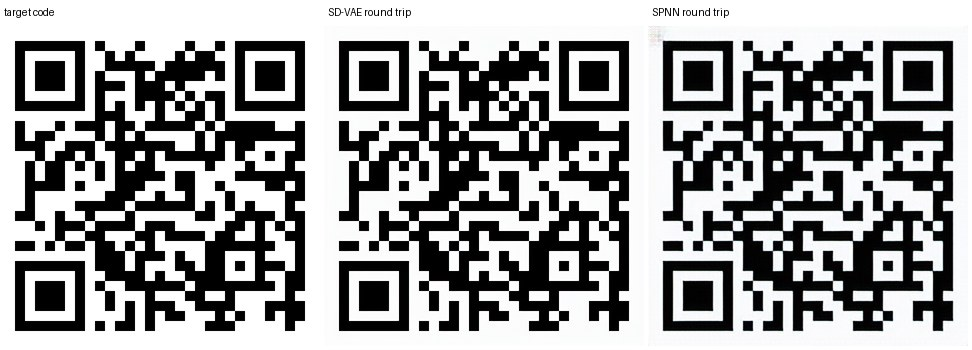

In [3]:
q = (qr * 2 - 1).to(dev)
print(f"target: {MESSAGE} | scanners on the plain code: {dq.scan(dq.to_u8(q)[0])} | module error {srpg.error_rate(q).item():.3f}")
tiles = [Image.fromarray(dq.to_u8(q)[0])]
with torch.no_grad():
    for n, c in CODECS.items():
        z = c.encode(q); r = c.decode(z); z2 = c.encode(r)
        print(f"{n:6s} round trip: scans {dq.scan(dq.to_u8(r)[0])} | module error {srpg.error_rate(r).item():.3f} "
              f"| idem {((z2 - z).norm() / z.norm()).item():.1e} | PSNR {10 * torch.log10(4 / (r.clamp(-1, 1) - q).pow(2).mean()).item():.1f} dB")
        tiles.append(Image.fromarray(dq.to_u8(r)[0]))
show_grid([(t, (lambda k: lambda i: tiles[k])(k)) for k, t in enumerate(["target code", "SD-VAE round trip", "SPNN round trip"])], [0], size=320)

## 1. Stage 1: ControlNet only
Plain DDIM with the QR ControlNet (Algorithm 1, lines 2-6). Stage 1 never touches the codec: each codec only decodes the final latent. The two columns therefore show the same latent through the two decoders, which is where the paper's ControlNet-only baseline (60% SSR) comes from.

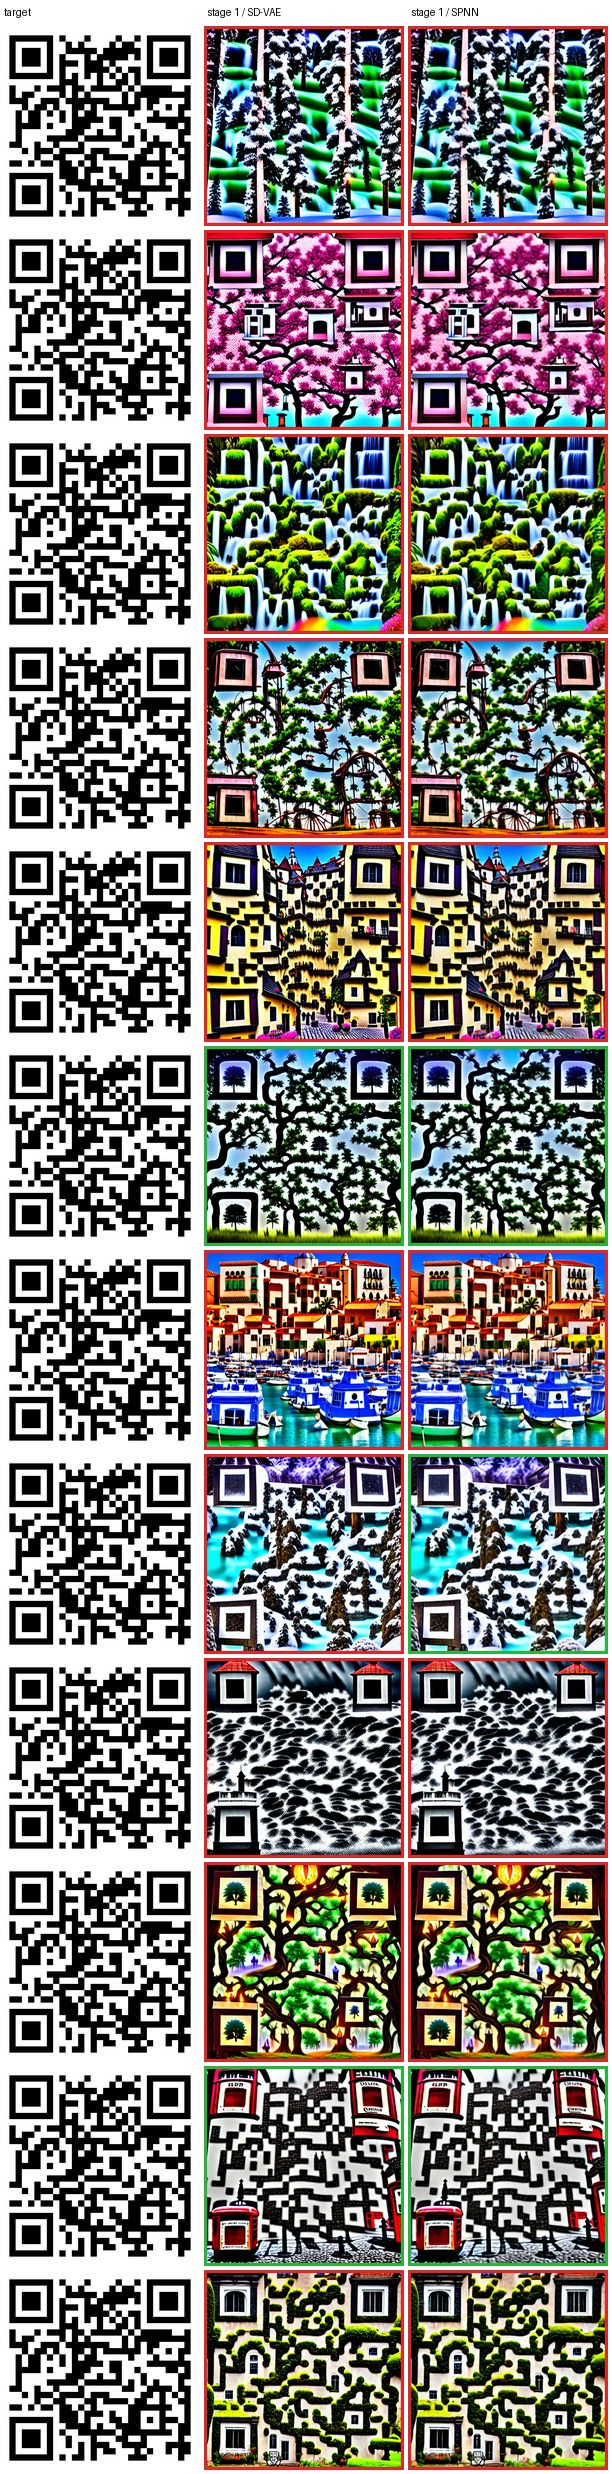

,n,SSR wechat,SSR zxing,SSR opencv,SSR opencv_aruco,SSR any,module err %,CLIP,s / img
variant,,,,,,,,,
stage1|SD-VAE,12,0.167,0.0,0.0,0.0,0.167,2.537,0.274,1.094
stage1|SPNN,12,0.250,0.0,0.0,0.0,0.250,2.556,0.275,1.094


In [4]:
EMB, ZT2, Z1 = {}, {}, {}
for i, p in enumerate(PROMPTS):
    EMB[i] = pipe.embed([p], NEG_PROMPT)
    g = torch.Generator(device=dev).manual_seed(SEED + i)
    zT = torch.randn(1, 4, 64, 64, device=dev, generator=g)
    ZT2[i] = torch.randn(1, 4, 64, 64, device=dev, generator=g)        # the repo's Stage 2 draws its own noise next
    Z1[i], sec = timed(lambda: pipe.stage1(EMB[i], COND, zT))
    with torch.no_grad():
        for n, c in CODECS.items():
            record(f"stage1|{n}", i, c.decode(Z1[i]), sec)
show_grid([("target", lambda i: Image.fromarray(dq.to_u8(q)[0])), ("stage 1 / SD-VAE", "stage1|SD-VAE"),
           ("stage 1 / SPNN", "stage1|SPNN")], range(len(PROMPTS)))
table(["stage1|SD-VAE", "stage1|SPNN"])

## 2. $\kappa$: the decoder gain the sandwich step has to supply
$\kappa = \|J_D^\top g\|^2 / \|g\|^2$ along the SRPG pixel gradient $g$, at each Stage-1 decode. It is measured on the SD-VAE decoder, the one the official gradient flows through. The same $\kappa$ is then used for **both** codecs, so the sandwich's pixel-space step is the same algorithm for both and only $E$ and $D$ differ. The SPNN's own value is printed for reference.

In [5]:
REF = {n: {i: (c.decode(Z1[i]).detach() / 2 + 0.5).clamp(0, 1) for i in Z1} for n, c in CODECS.items()}   # Stage-1 image per codec, [0,1]
kap = {n: torch.cat([dq.estimate_kappa(c, Z1[i], srpg, REF[n][i]) for i in Z1]) for n, c in CODECS.items()}
for n, v in kap.items():
    print(f"kappa along g, {n:6s} decoder: median {v.median():.4g}  (min {v.min():.4g}, max {v.max():.4g})")
kappa = float(kap["SD-VAE"].median()) if KAPPA is None else KAPPA
print(f"sandwich step c_t = {PIXEL_STEP} * {kappa:.4g} * (1 - a_t): {PIXEL_STEP * kappa * (1 - pipe.alpha(pipe.timesteps[0])):.4g} at the first step, "
      f"{PIXEL_STEP * kappa * (1 - pipe.alpha(pipe.timesteps[-1])):.3g} at the last")

/home/ron.libman/churches-reboot/DiffQRCoder-main/diffqrcoder/losses/perceptual_loss.py:64: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  torch.tensor(


kappa along g, SD-VAE decoder: median 27.23  (min 17.17, max 59.48)
kappa along g, SPNN   decoder: median 19.52  (min 14.37, max 550.4)
sandwich step c_t = 1.0 * 27.23 * (1 - a_t): 27.06 at the first step, 0.0464 at the last


## 3. Stage 2 with SRPG: official (`grad`) vs latent (`sandwich`), SD-VAE vs SPNN
Four runs per prompt. Each uses the same Stage-2 noise and the same target code, with its own codec's Stage-1 image as the perceptual reference. `grad` backpropagates through the codec's decoder, the UNet and the ControlNet. `sandwich` does one decode and one encode per step, with no backprop through either.

prompt 0: grad|SD-VAE err 0.000 no  | grad|SPNN err 0.000 no  | sandwich|SD-VAE err 0.013 no  | sandwich|SPNN err 0.010 no 


prompt 1: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.000 OK  | sandwich|SD-VAE err 0.008 no  | sandwich|SPNN err 0.006 no 


prompt 2: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.000 OK  | sandwich|SD-VAE err 0.011 no  | sandwich|SPNN err 0.006 OK 


prompt 3: grad|SD-VAE err 0.001 OK  | grad|SPNN err 0.001 OK  | sandwich|SD-VAE err 0.012 no  | sandwich|SPNN err 0.005 no 


prompt 4: grad|SD-VAE err 0.473 no  | grad|SPNN err 0.411 no  | sandwich|SD-VAE err 0.010 OK  | sandwich|SPNN err 0.010 no 


...

prompt 7: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.000 OK  | sandwich|SD-VAE err 0.001 no  | sandwich|SPNN err 0.004 OK 


prompt 8: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.000 OK  | sandwich|SD-VAE err 0.004 no  | sandwich|SPNN err 0.005 no 


prompt 9: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.007 OK  | sandwich|SD-VAE err 0.000 no  | sandwich|SPNN err 0.004 no 


prompt 10: grad|SD-VAE err 0.000 OK  | grad|SPNN err 0.000 OK  | sandwich|SD-VAE err 0.007 no  | sandwich|SPNN err 0.007 no 


prompt 11: grad|SD-VAE err 0.030 OK  | grad|SPNN err 0.317 no  | sandwich|SD-VAE err 0.006 no  | sandwich|SPNN err 0.005 no 


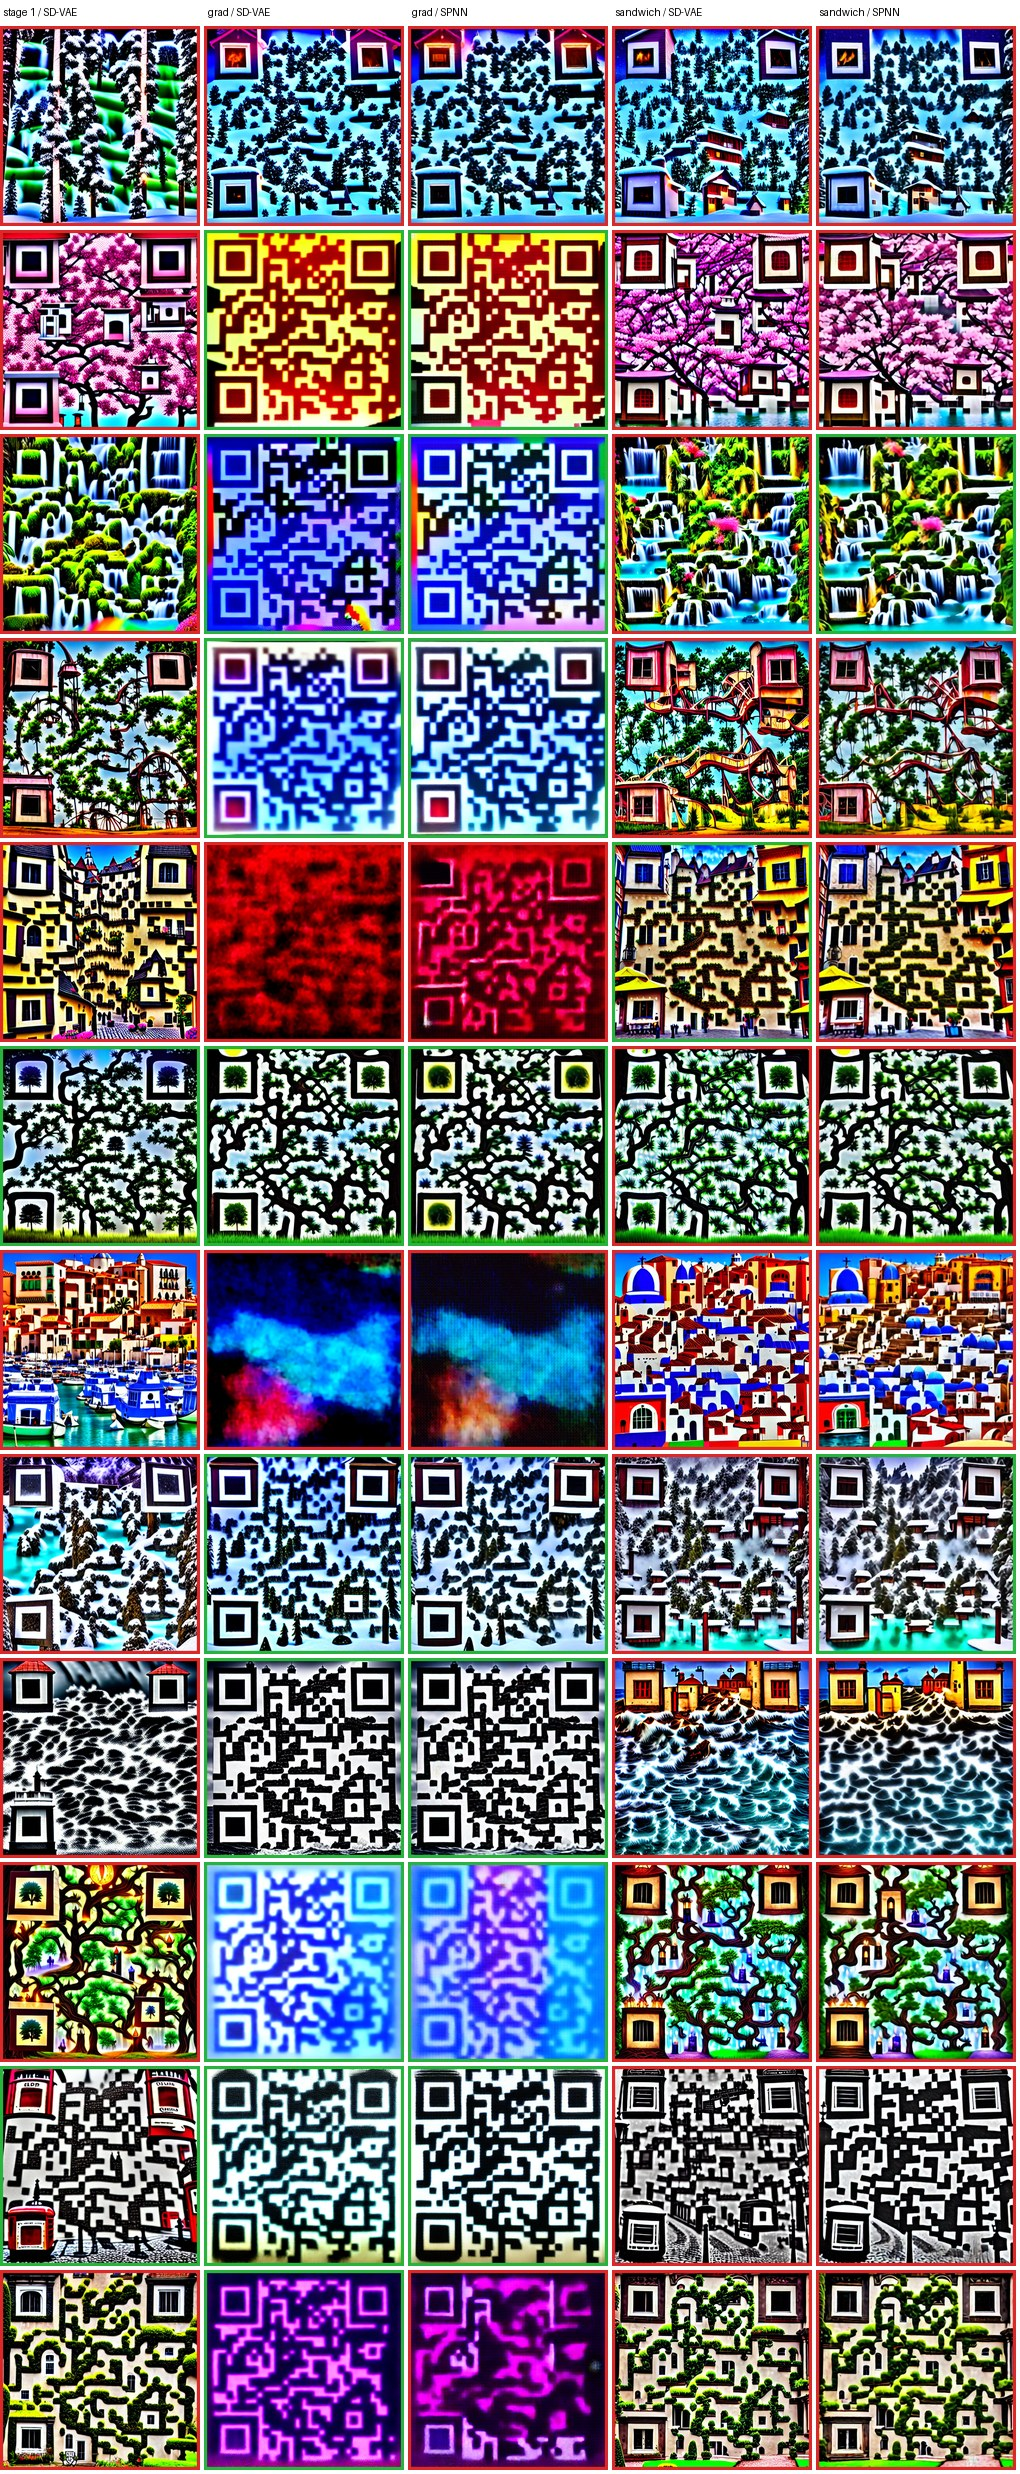

,n,SSR wechat,SSR zxing,SSR opencv,SSR opencv_aruco,SSR any,module err %,CLIP,s / img
variant,,,,,,,,,
stage1|SD-VAE,12,0.167,0.000,0.000,0.000,0.167,2.537,0.274,1.094
grad|SD-VAE,12,0.750,0.167,0.083,0.083,0.750,7.342,0.219,9.272
grad|SPNN,12,0.667,0.250,0.000,0.000,0.667,9.542,0.211,4.494
sandwich|SD-VAE,12,0.083,0.000,0.000,0.000,0.083,0.674,0.274,5.805
sandwich|SPNN,12,0.167,0.000,0.000,0.000,0.167,0.585,0.277,2.630


In [6]:
VARIANTS = [(m, n) for m in ("grad", "sandwich") for n in CODECS]
Z2, TRACE = defaultdict(dict), defaultdict(dict)
a_T = pipe.alpha(pipe.timesteps[0])
for i in range(len(PROMPTS)):
    for mode, n in VARIANTS:
        c = CODECS[n]
        if STAGE2_INIT == "stage1":                                   # Algorithm 1, line 9, with this codec's E
            with torch.no_grad():
                z_init = a_T ** 0.5 * c.encode(REF[n][i] * 2 - 1) + (1 - a_T) ** 0.5 * ZT2[i]
        else:
            z_init = ZT2[i]
        (z, tr), sec = timed(lambda: pipe.stage2(EMB[i], COND, z_init, c, srpg, REF[n][i], mode=mode, kappa=kappa, pixel_step=PIXEL_STEP))
        Z2[f"{mode}|{n}"][i], TRACE[f"{mode}|{n}"][i] = z, tr["err"][0]
        with torch.no_grad():
            record(f"{mode}|{n}", i, c.decode(z), sec)
    print(f"prompt {i}: " + " | ".join(f"{v} err {R[v][i]['err']:.3f} {'OK ' if scanned(R[v][i]) else 'no '}" for v in Z2), flush=True)
S2 = [f"{m}|{n}" for m, n in VARIANTS]
show_grid([("stage 1 / SD-VAE", "stage1|SD-VAE")] + [(v.replace("|", " / "), v) for v in S2], range(len(PROMPTS)))
table(["stage1|SD-VAE"] + S2)

## 4. Module error rate of $D(z_{0|t})$ during Stage 2 (the paper's Fig. 9a)
The mean over prompts, on a log scale. In the paper, the official guidance removes most errors within the first five steps.

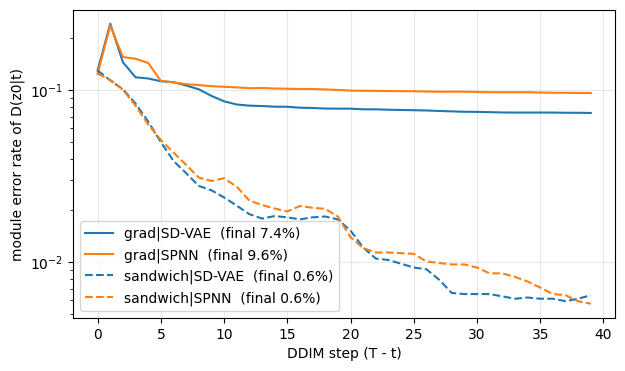

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for v, st in zip(S2, ["-", "-", "--", "--"]):
    tr = torch.stack([TRACE[v][i] for i in TRACE[v]])
    ax.plot(tr.mean(0).numpy(), st, label=f"{v}  (final {100 * tr[:, -1].mean():.1f}%)", color="tab:blue" if "VAE" in v else "tab:orange")
ax.set_yscale("log"); ax.set_xlabel("DDIM step (T - t)"); ax.set_ylabel("module error rate of D(z0|t)"); ax.grid(alpha=0.3); ax.legend()
plt.show()

## 5. SR-MPGD post-processing
`SRMPGD_ITERS` iterations on top of each Stage-2 result. `grad` is the repo's SGD on the latent through the decoder. `sandwich` is projected gradient descent in pixel space, $x \leftarrow D(E(x - \gamma\kappa\nabla_x L))$. For the SPNN, $D\circ E$ is an exact projection (idempotent), so the iterate is always a point of the codec's image.

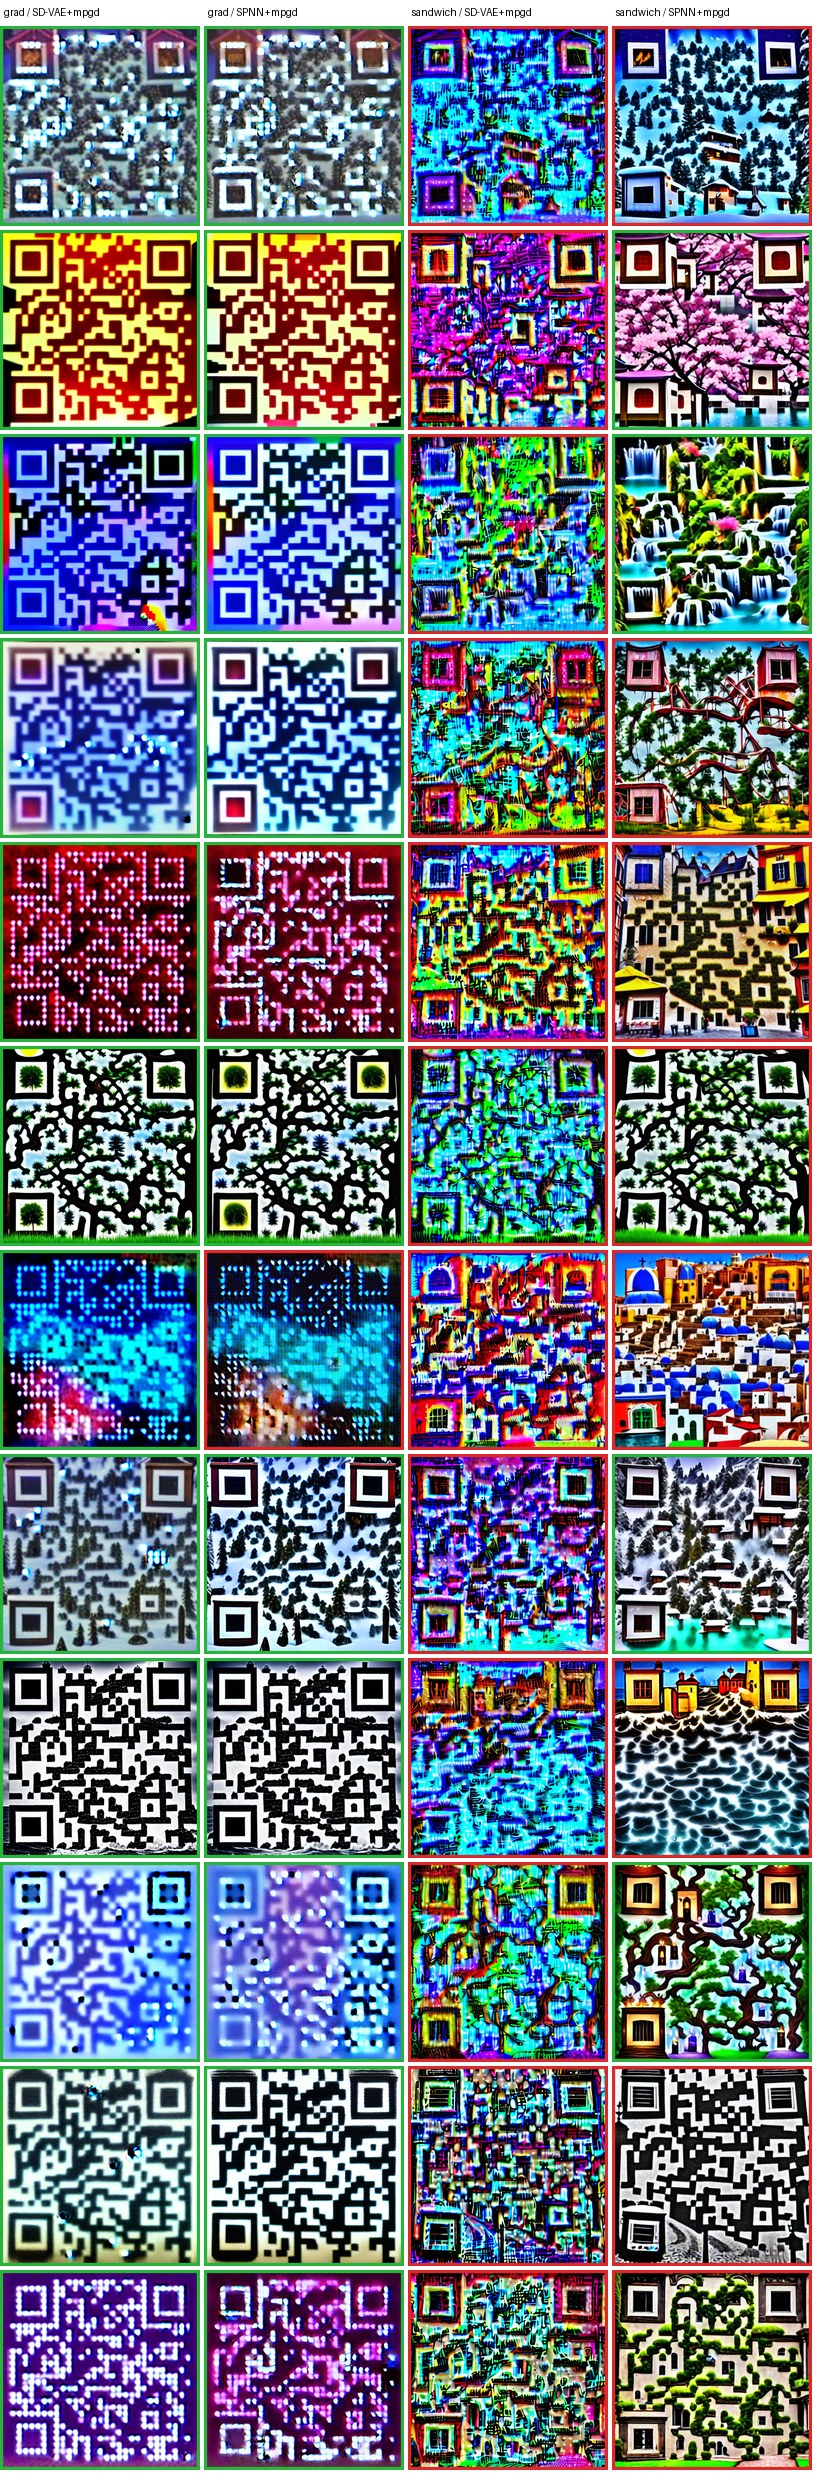

,n,SSR wechat,SSR zxing,SSR opencv,SSR opencv_aruco,SSR any,module err %,CLIP,s / img
variant,,,,,,,,,
grad|SD-VAE,12,0.750,0.167,0.083,0.083,0.750,7.342,0.219,9.272
grad|SPNN,12,0.667,0.250,0.000,0.000,0.667,9.542,0.211,4.494
sandwich|SD-VAE,12,0.083,0.000,0.000,0.000,0.083,0.674,0.274,5.805
sandwich|SPNN,12,0.167,0.000,0.000,0.000,0.167,0.585,0.277,2.630
grad|SD-VAE+mpgd,12,1.000,0.167,0.000,0.083,1.000,0.030,0.212,3.152
grad|SPNN+mpgd,12,0.917,0.250,0.000,0.083,0.917,0.000,0.209,0.909
sandwich|SD-VAE+mpgd,12,0.000,0.000,0.000,0.000,0.000,0.178,0.216,2.299
sandwich|SPNN+mpgd,12,0.333,0.000,0.000,0.000,0.333,0.000,0.278,0.714


In [8]:
for i in range(len(PROMPTS)):
    for mode, n in VARIANTS:
        c, v = CODECS[n], f"{mode}|{n}"
        (z, errs), sec = timed(lambda: pipe.srmpgd(Z2[v][i], c, srpg, REF[n][i], mode=mode, iters=SRMPGD_ITERS, lr=SRMPGD_LR, kappa=kappa))
        with torch.no_grad():
            record(v + "+mpgd", i, c.decode(z), sec)
S3 = [v + "+mpgd" for v in S2]
show_grid([(v.replace("|", " / "), v) for v in S3], range(len(PROMPTS)))
table(S2 + S3)

## 6. Summary
SSR = fraction of prompts whose image decodes to exactly the target URL, per decoder and for any of them. `module err %` is paper Eq. 19. `s / img` is wall time per image for that stage alone (Stage 2, or the SR-MPGD iterations), on this GPU.

In [9]:
summary = table(["stage1|SD-VAE", "stage1|SPNN"] + S2 + S3)
summary.to_csv(OUT / "summary.csv")
cfg = {k: globals()[k] for k in ["MESSAGE", "QR_VERSION", "QR_EC", "QR_MASK", "MODULE_SIZE", "SEED", "STEPS", "CFG", "CN_SCALE", "NEG_PROMPT",
                                  "LAM_SR", "LAM_PERC", "PERCEPTUAL", "STAGE2_INIT", "PIXEL_STEP", "SRMPGD_ITERS", "SRMPGD_LR", "USE_EMA", "CKPT"]}
json.dump({"config": {**cfg, "kappa": kappa, "prompts": PROMPTS}, "per_image": R}, open(OUT / "results.json", "w"), indent=1)
print(f"saved {OUT}/summary.csv, results.json, imgs/")
summary

saved /rg/shocher_prj/ron.libman/laion1m/runs/spnn512/diffqr/summary.csv, results.json, imgs/


,n,SSR wechat,SSR zxing,SSR opencv,SSR opencv_aruco,SSR any,module err %,CLIP,s / img
variant,,,,,,,,,
stage1|SD-VAE,12,0.167,0.000,0.000,0.000,0.167,2.537,0.274,1.094
stage1|SPNN,12,0.250,0.000,0.000,0.000,0.250,2.556,0.275,1.094
grad|SD-VAE,12,0.750,0.167,0.083,0.083,0.750,7.342,0.219,9.272
grad|SPNN,12,0.667,0.250,0.000,0.000,0.667,9.542,0.211,4.494
sandwich|SD-VAE,12,0.083,0.000,0.000,0.000,0.083,0.674,0.274,5.805
sandwich|SPNN,12,0.167,0.000,0.000,0.000,0.167,0.585,0.277,2.630
grad|SD-VAE+mpgd,12,1.000,0.167,0.000,0.083,1.000,0.030,0.212,3.152
grad|SPNN+mpgd,12,0.917,0.250,0.000,0.083,0.917,0.000,0.209,0.909
sandwich|SD-VAE+mpgd,12,0.000,0.000,0.000,0.000,0.000,0.178,0.216,2.299


## 7. Inside the sandwich (first prompt)
For each codec, per Stage-2 step (sandwich mode):
- `drift` $= \|E(D(z_{0|t})) - z_{0|t}\| / \|z_{0|t}\|$ is what one decode-encode round trip changes with no guidance. It is 0 for an idempotent codec.
- The module error of the prediction $D(z_{0|t})$, of the guided image $x'$, and of its projection $D(E(x'))$. The gap between the last two shows how much of the pixel step the codec keeps.

SD-VAE: drift mean 2.29e-01 | error after projection minus error of the guided image, mean over steps: 0.07 points


SPNN  : drift mean 6.86e-07 | error after projection minus error of the guided image, mean over steps: 0.18 points


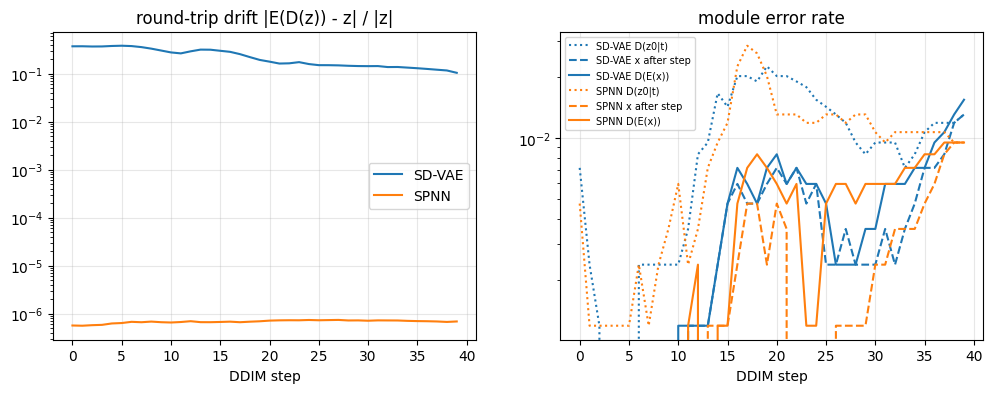

In [10]:
i = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n, col in (("SD-VAE", "tab:blue"), ("SPNN", "tab:orange")):
    _, tr = pipe.stage2(EMB[i], COND, ZT2[i], CODECS[n], srpg, REF[n][i], mode="sandwich", kappa=kappa, pixel_step=PIXEL_STEP, diag=True)
    axes[0].plot(tr["drift"][0].clamp_min(1e-8).numpy(), color=col, label=n)
    for k, st in (("err", ":"), ("err_step", "--"), ("err_proj", "-")):
        axes[1].plot(tr[k][0].numpy(), st, color=col, label=f"{n} {dict(err='D(z0|t)', err_step='x after step', err_proj='D(E(x))')[k]}")
    print(f"{n:6s}: drift mean {tr['drift'].mean():.2e} | error after projection minus error of the guided image, mean over steps: "
          f"{100 * (tr['err_proj'] - tr['err_step']).mean():.2f} points")
axes[0].set_yscale("log"); axes[0].set_title("round-trip drift |E(D(z)) - z| / |z|"); axes[0].set_xlabel("DDIM step"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_yscale("log"); axes[1].set_title("module error rate"); axes[1].set_xlabel("DDIM step"); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.show()